In [1]:
# Loading modules

%matplotlib inline
import numpy as np
import glob, os, sys, time
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from scipy.interpolate import interp1d
from PTEmu import PTEmu

# Setup of emulator

In [2]:
# Parameter ranges (not necessary after the training samples have been generated, but useful to know!)
ranges = {}
ranges['s12'] = [0.2, 1.0]
ranges['wc'] = [0.07, 0.16]
ranges['wb'] = [0.0217, 0.0225]
ranges['ns'] = [0.955, 0.965]
ranges['alpha_tr'] = [0.7, 1.3]
ranges['alpha_lo'] = [0.7, 1.3]
ranges['f'] = [0.5, 1.0]
ranges['avir'] = [0., 5.]

## Redshift space

In [8]:
# define which parameters are "shape" and "RSD" parameters
params_definition = {'wc':'shape','wb':'shape','ns':'shape',
                     's12':'RSD','alpha_tr':'RSD','alpha_lo':'RSD','f':'RSD'}

# create instance of emulator class
EFT = PTEmu(params=params_definition)

In [9]:
# load samples: there are different set of samples for the linear Pk and sigma12 emulators 
# (only dependent on shape parameters) and the full parameter set (shape + RSD parameters)
EFT.load_samples(fname='../params/params_lhc_wcwbns_n500.dat', type='shape')
EFT.load_samples(fname='../params/params_lhc_wcwbns_sig12APf_n2000.dat', type='all')

In [10]:
# load model tables (note that for type=shape one needs to specify the data_type as well: PL or s12)
EFT.load_table(fname='../tables/training_set_lhc_wcwbns_n500_zs.dat', type='shape', data_type='PL')
EFT.load_table(fname='../tables/sigma12_training_set_lhc_wcwbns_n500_zs.dat', type='shape', data_type='s12')
EFT.load_table(fname='../tables/training_set_lhc_wcwbns_sig12APf_n2000_zs.dat', type='all')

In [11]:
# let's first train the emulator for PL and s12, which are model independent and can be re-used later
EFT.train_emulator(data_type=['PL','s12'])
EFT.save_emulator(fname_base='../models/Emu_shape', data_type=['PL','s12'])

# after the training, the emulators can be loaded as follows:
# EFT.load_emulator(fname_base='../models/Emu_shape', data_type=['PL','s12'])

In [12]:
# now we train the emulator for the full parameter set (remember: this is model dependent!)
EFT.train_emulator(data_type=[0,2,4])
EFT.save_emulator(fname_base'../models/EFT', data_type=[0,2,4])

# after the training, the emulator can be loaded as follows:
# EFT.load_emulator(fname_base='../models/EFT', data_type=[0,2,4])

## Real space

In [3]:
# define which parameters are "shape" and "RSD" parameters 
# (for real space we remove the growth rate and set it to zero when computing the model table)
params_definition = {'wc':'shape','wb':'shape','ns':'shape',
                     's12':'RSD','alpha_tr':'RSD','alpha_lo':'RSD'}

# create instance of emulator class
PRS = PTEmu(params=params_definition)

In [4]:
# load samples (we use the same samples for the shape parameters as before, but a different set for the full parameter space)
PRS.load_samples(fname='../params/params_lhc_wcwbns_n500.dat', type='shape')
PRS.load_samples(fname='../params/params_lhc_wcwbns_sig12AP_feq0_n2000.dat', type='all')

In [5]:
# load model tables
PRS.load_table(fname='../tables/training_set_lhc_wcwbns_n500_zs.dat', type='shape', data_type='PL')
PRS.load_table(fname='../tables/sigma12_training_set_lhc_wcwbns_n500_zs.dat', type='shape', data_type='s12')
PRS.load_table(fname='../tables/training_set_lhc_wcwbns_sig12AP_feq0_n2000.dat', type='all')

In [6]:
# we have already trained the emualtors for PL and s12 above, so we can simply load them back into memory
PRS.load_emulator(fname_base='../models/Emu_shape', data_type=['PL','s12'])

In [7]:
# now we train the emulator for the full parameter set (here we only need the monopole)
PRS.train_emulator(data_type=0)
PRS.save_emulator(fname_base='../models/EFT_feq0', data_type=0)

# after the training, the emulator can be loaded as follows:
# PRS.load_emulator('../models/EFT_feq0', data_type=0)

# Making predictions

## Definition of data set and background cosmology

In [52]:
# we define the data set by specifying the k-bins of the measurements, the measured multipoles, 
# the covariance matrix, and the number density of the tracers
nbar = 3.95898e-4 # this must be in units of (h/Mpc)^3

# data and covariance must be in Mpc units (without little h)
data = np.loadtxt('../data/Minerva_HOD_zs_z0.57_pkmulti_mean.dat')
cov = np.loadtxt('../data/Minerva_HOD_zs_z0.57_pkmulti_covar.dat')

# if theory_cov=False the Anderson-Hartlap factor is computed for the inverse covariance, 
# so the number of realisations from which the covariance matrix was estimated needs to be specified 
# (otherwise it can be ignored)
EFT.define_data_set(k=data[:,0], obs=data[:,[1,3,5]], cov=cov, nbar=nbar, theory_cov=False, Nrealizations=300)

# now for the real-space data:
data = np.loadtxt('../data/Minerva_HOD_rs_z0.57_pkmulti_mean.dat')
cov = np.loadtxt('../data/Minerva_HOD_rs_z0.57_pkmulti_covar.dat')

PRS.define_data_set(k=data[:,0], obs=data[:,1], cov=cov, nbar=nbar, theory_cov=False, Nrealizations=300)

In [14]:
# if we want to make use of generating predictions using the LCDM parameter space (instead of s12 etc), 
# we need to define the fiducial background cosmology: background parameters + redshift
params_fid_Minerva = {'h':0.695, 'wc':0.11544, 'wb':0.0222191, 'z':0.57}

EFT.define_fiducial_cosmology(params_fid=params_fid_Minerva)
PRS.define_fiducial_cosmology(params_fid=params_fid_Minerva)

## Predictions using the RSD parameter space

In [15]:
# the functions returning the multipoles (or chi-square) take generally two arguments: 
# 1. a parameter dictionary, specifying shape + RSD parameters, as well as bias parameters
# 2. the multipole number, i.e. ell = 0, 2, 4, or a list of multipole numbers

# let's create a parameter dictionary
params = {}

# we always need to specify the shape parameter values
params['wc'] = 0.11544
params['wb'] = 0.0222191
params['ns'] = 0.9632

# for predictions usinf the RSD parameter space we also need to specify values for the following four parameters
params['s12']      = 0.6
params['alpha_lo'] = 1.1
params['alpha_tr'] = 0.9
params['f']        = 0.7

# finally, the bias parameters: any parameters from {b1, b2, g2, g21, c0, c2, c4, cnlo, N0, N20, N22} can be specified
# parameter, which are not explicitly specified are automatically set to zero
# as an example, let's just b1 and b2:
params['b1'] = 2.
params['b2'] = -0.5

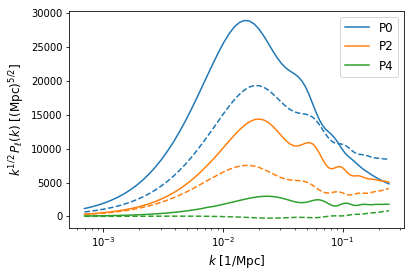

In [16]:
f = plt.figure()
ax = f.add_subplot(111)

# let's generate the predictions for the monopole, quadrupole and hexadecapole 
# (the output is given for the k-values specified by EFT.k_table (in units of h/Mpc), 
# while the multipoles are in units of Mpc... need to make this more consistent!)
Pzs1 = EFT.Pell(params, ell=[0,2,4])

# now, let's generate a second set of predictions after changing some parameter values
params['alpha_tr'] = 1.2
params['g2']       = -0.3
params['c0']       = -4.
params['cnlo']     = 6.
params['N0']       = 0.6
Pzs2 = EFT.Pell(params, ell=[0,2,4])

# convert to 1/Mpc
k_table = EFT.k_table*EFT.fid_LCDM_params['h']

# plot!
ax.semilogx(k_table, k_table**0.5*Pzs1[:,0],c='C0',ls='-',label='P0')
ax.semilogx(k_table, k_table**0.5*Pzs2[:,0],c='C0',ls='--')

ax.semilogx(k_table, k_table**0.5*Pzs1[:,1],c='C1',ls='-',label='P2')
ax.semilogx(k_table, k_table**0.5*Pzs2[:,1],c='C1',ls='--')

ax.semilogx(k_table, k_table**0.5*Pzs1[:,2],c='C2',ls='-',label='P4')
ax.semilogx(k_table, k_table**0.5*Pzs2[:,2],c='C2',ls='--')

ax.set_xlabel('$k$ [1/Mpc]',fontsize=12)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc})^{5/2}$]',fontsize=12)
ax.legend(fontsize=12)

## Predictions using the LCDM parameter space

In [17]:
# when making use of the LCDM parameter space, we need to specify values for the Hubble rate, amplitude of scalar
# fluctuations, and redshift (in addition to the three shape parameters from before)
params['h']  = 0.8
params['As'] = 2.3
params['z']  = 0.6

# we then call the following function, which takes the same arguments as above and gives the same output
Pzs_LCDM = EFT.Pell_LCDM(params, ell=[0,2,4])

# we can also specfiy an additional argument (alpha_tr_lo), which allows us to set the AP parameters by hand 
# (useful if we want to run with fixed AP parameters in real space for example)
Prs_LCDM = PRS.Pell_LCDM(params, ell=0, alpha_tr_lo=[1,1])

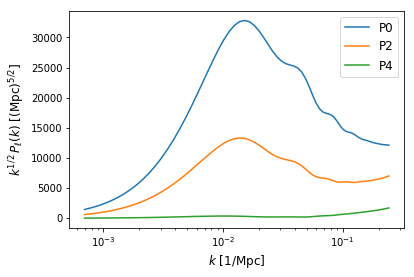

In [18]:
# Redshift space plot
f = plt.figure()
ax = f.add_subplot(111)

# convert to 1/Mpc
k_table = EFT.k_table*EFT.fid_LCDM_params['h']

# plot!
ax.semilogx(k_table, k_table**0.5*Pzs_LCDM[:,0],c='C0',ls='-',label='P0')
ax.semilogx(k_table, k_table**0.5*Pzs_LCDM[:,1],c='C1',ls='-',label='P2')
ax.semilogx(k_table, k_table**0.5*Pzs_LCDM[:,2],c='C2',ls='-',label='P4')

ax.set_xlabel('$k$ [1/Mpc]',fontsize=12)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc})^{5/2}$]',fontsize=12)
ax.legend(fontsize=12)

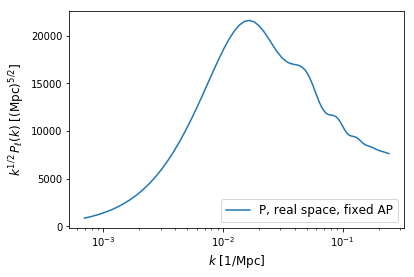

In [19]:
# Real space plot
f = plt.figure()
ax = f.add_subplot(111)

# convert to 1/Mpc
k_table = EFT.k_table*EFT.fid_LCDM_params['h']

# plot!
ax.semilogx(k_table, k_table**0.5*Prs_LCDM,c='C0',ls='-',label='P, real space, fixed AP')

ax.set_xlabel('$k$ [1/Mpc]',fontsize=12)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc})^{5/2}$]',fontsize=12)
ax.legend(fontsize=12)

## Computing chi-squares

In [51]:
# chi-squares are computed using a single function and we can speficy whether we want to use the RSD or LCDM 
# parameter spaces via the argument 'mode' by setting it to 'generic' or 'LCDM'

# the arguments are:
# 1. parameter dictionary as above
# 2. list of kmax in units of 1/Mpc (if a single number is given instead of a list, the same kmax for all three multipoles is assumed)
# 3. mode

chi2A = EFT.chi2(params, kmax=[0.2,0.15,0.1], mode='generic')
chi2B = EFT.chi2(params, kmax=[0.2,0.15,0.1], mode='LCDM')
chi2C = PRS.chi2(params, kmax=0.2, mode='LCDM')

# for the LCDM mode one can also specify the alpha_tr_lo argument as described above

print(chi2A, chi2B, chi2C)

932.5860482021201 747.7402868979829 11297.660276135099
